Brain Tumor Classification using CNN and Tensorflow with Deployment


In [11]:
#Importing libraries and tools
import os
import numpy as np
import random
import tensorflow as tf

In [39]:
from PIL import Image,ImageEnhance 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import vgg16
from sklearn.utils import shuffle


Loading the Dataset

In [ ]:
train_dir=r'C:\Users\Sravani\Downloads\MRI Tumor Detection\Training'

In [25]:
train_dir

'C:\\Users\\Sravani\\Downloads\\MRI Tumor Detection\\Training'

In [1]:

test_dir=r'C:\Users\Sravani\Downloads\MRI Tumor Detection\Testing'

In [27]:
test_dir

'C:\\Users\\Sravani\\Downloads\\MRI Tumor Detection\\Testing'

In [28]:
train_data=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',#4classes
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 5600 files belonging to 4 classes.


In [29]:
test_data=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',#4classes
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 1600 files belonging to 4 classes.


Visualization 

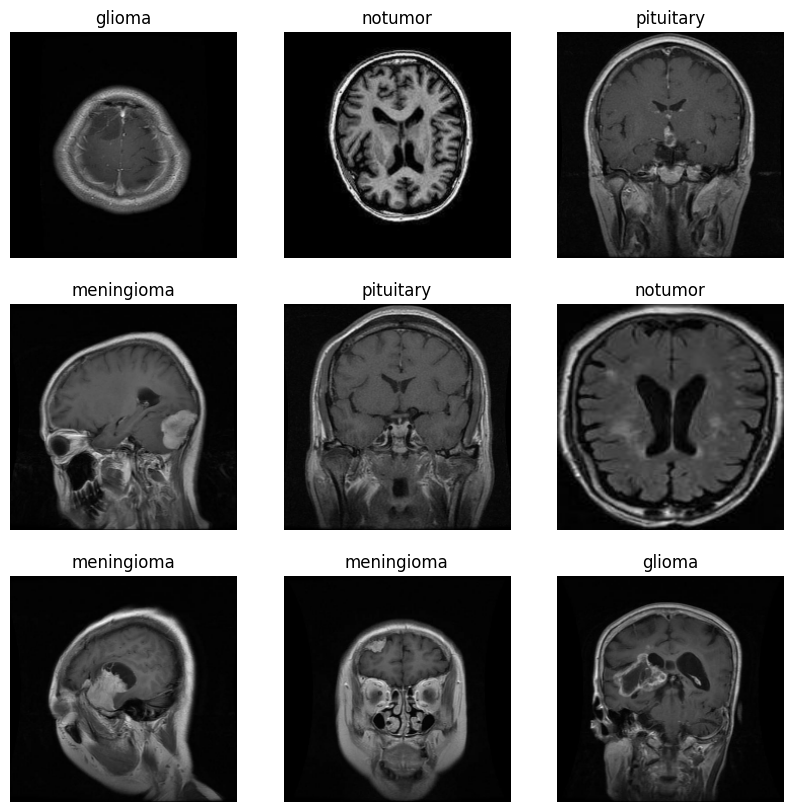

In [30]:
import random
import matplotlib.pyplot as plt


class_names = train_data.class_names
plt.figure(figsize=(10,10))


for images,labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_index=np.argmax(labels[i].numpy())
        plt.title(class_names[class_index])
        plt.axis("off")


plt.show()    

Normalization of Images

In [31]:
from tensorflow.keras.layers import Rescaling

normaliztion_layerl=Rescaling(1./255)

train_data=train_data.map(
    lambda images,labels:(normaliztion_layerl(images),labels)
)

test_data=test_data.map(
    lambda images,labels:(normaliztion_layerl(images),labels)
)



In [32]:
import tensorflow as tf



print(tf.keras.layers)
print(type(tf.keras.layers))

<module 'tensorflow.keras.layers' from 'c:\\Users\\Sravani\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\keras\\_tf_keras\\keras\\layers\\__init__.py'>
<class 'module'>


In [33]:
for images,labels in train_data.take(1):
    print("Minimum pixel Value:",images[0].numpy().min())
    print("Maximum pixel value:",images[0].numpy().max())

Minimum pixel Value: 0.0
Maximum pixel value: 0.9991676


Model Building

In [48]:
model=Sequential()
model.add(Input(shape=(224,224,3)))
model.add(Conv2D(
          filters=32,
          kernel_size=(3,3),
          activation='relu'
))

In [ ]:
from tensorflow.keras.layers import MaxPooling2D
model.add(MaxPooling2D(2,2))


In [55]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D

model = Sequential()

model.add(Input(shape=(224,224,3)))

# Block 1
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))

In [63]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,202,500 (42.73 MB)

 Trainable params: 11,202,500 (42.73 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))

In [80]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10


c:\Users\Sravani\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 143s 797ms/step - accuracy: 0.4420 - loss: 1.2135 - val_accuracy: 0.5006 - val_loss: 1.2024
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 127s 723ms/step - accuracy: 0.6604 - loss: 0.8105 - val_accuracy: 0.6244 - val_loss: 1.0679
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 707ms/step - accuracy: 0.6954 - loss: 0.6877 - val_accuracy: 0.6488 - val_loss: 0.9295
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 720ms/step - accuracy: 0.7207 - loss: 0.6013 - val_accuracy: 0.6631 - val_loss: 0.9718
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 706ms/step - accuracy: 0.7405 - loss: 0.5658 - val_accuracy: 0.7019 - val_loss: 0.8701
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 708ms/step - accuracy: 0.8075 - loss: 0.4829 - val_accuracy: 0.7487 - val_loss: 0.8019
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 125s 710ms/step - accuracy: 0.8648 - loss: 0.3975 - val_accuracy: 0.7650 - val_loss: 0.8377
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 703ms/step - accuracy: 0.8893 - loss: 0.34

In [73]:
for images, labels in train_data.take(1):
    print(labels.shape)
    print(labels[0])
    break

(32, 4)
tf.Tensor([0. 1. 0. 0.], shape=(4,), dtype=float32)


In [76]:
print(type(train_data))

<class 'tensorflow.python.data.ops.map_op._MapDataset'>


Traning the Model


In [77]:
for images,labels in train_data.take(1):
    print("Images shape:",images.shape)
    print("Labels shape:", labels.shape)
    print("First label:", labels[0])
          

Images shape: (32, 224, 224, 3)
Labels shape: (32, 4)
First label: tf.Tensor([0. 1. 0. 0.], shape=(4,), dtype=float32)


In [82]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10


c:\Users\Sravani\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 135s 772ms/step - accuracy: 0.9611 - loss: 0.1641 - val_accuracy: 0.8469 - val_loss: 0.7982
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 108s 576ms/step - accuracy: 0.9648 - loss: 0.1466 - val_accuracy: 0.8388 - val_loss: 0.8297
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 108s 618ms/step - accuracy: 0.9564 - loss: 0.1859 - val_accuracy: 0.8406 - val_loss: 0.7640
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 120s 685ms/step - accuracy: 0.9657 - loss: 0.1452 - val_accuracy: 0.8487 - val_loss: 0.7652
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 673ms/step - accuracy: 0.9711 - loss: 0.1338 - val_accuracy: 0.8356 - val_loss: 0.8563
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 676ms/step - accuracy: 0.9762 - loss: 0.1095 - val_accuracy: 0.8481 - val_loss: 0.8587
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 129s 735ms/step - accuracy: 0.9775 - loss: 0.1058 - val_accuracy: 0.8669 - val_loss: 0.7633
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 133s 758ms/step - accuracy: 0.9725 - loss: 0.11

In [83]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


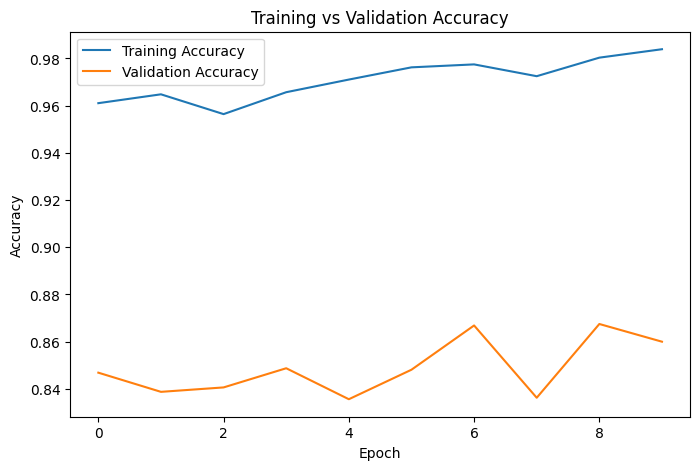

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

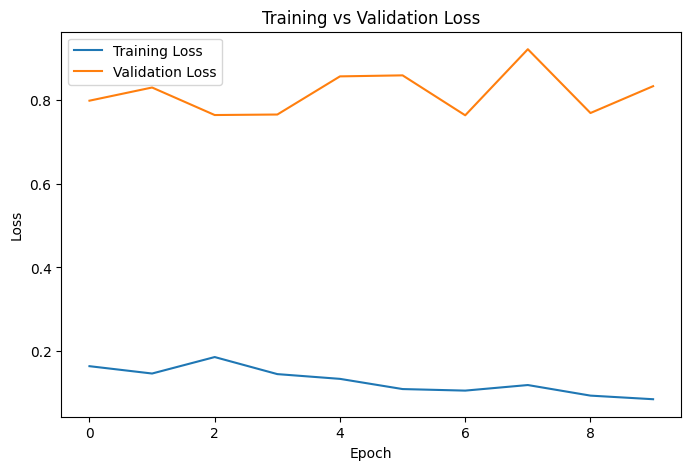

In [85]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [86]:
model.save("Brain_tumor_cnn.keras")

In [88]:
from tensorflow.keras.models import load_model
model=load_model("Brain_tumor_cnn.keras")

In [107]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
imag_path=r"C:\Users\Sravani\Downloads\MRI Tumor Detection\Testing\glioma\Te-gl_4.jpg"
img=image.load_img(imag_path,target_size=(224,224))
img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array=np.expand_dims(img_array,axis=0)

prediction=model.predict(img_array)

print(prediction)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[9.9749529e-01 2.4941093e-03 5.9031445e-06 4.6476816e-06]]


In [108]:
import numpy as np

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Predicted Class: glioma
Confidence: 99.75%


In [94]:
model = load_model("Brain_tumor_cnn.keras")

In [99]:
train_data=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

class_names=train_data.class_names
print(class_names)

Found 5600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [100]:
print(train_data.class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']
